In [ ]:
# Import dependencies
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss, accuracy_score
from tqdm import tqdm
import shap
import math
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
# Start SHAP
shap.initjs()

In [ ]:
# Read the preprocessed data csv as a DataFrame
preprocess_data_df = pd.read_csv("preprocessed_case_data_a.csv")

# Preview the preprocessed data
preprocess_data_df.head()

,caseId,term,naturalCourt,petitioner,respondent,jurisdiction,threeJudgeFdc,caseOrigin,caseSource,lcDisagreement,lcDisposition,lcDispositionDirection,partyWinning,issue,issueArea,lawType,lawSupp
0,1946-001,1946,1301,198.0,172.0,6.0,0.0,51.0,29.0,0.0,2.0,1.0,1.0,80180.0,8.0,6.0,600.0
1,1946-002,1946,1301,100.0,27.0,1.0,0.0,123.0,30.0,0.0,2.0,1.0,0.0,10500.0,1.0,6.0,600.0
2,1946-002,1946,1301,100.0,27.0,1.0,0.0,123.0,30.0,0.0,2.0,1.0,0.0,10500.0,1.0,6.0,600.0
3,1946-002,1946,1301,100.0,27.0,1.0,0.0,123.0,30.0,0.0,2.0,1.0,0.0,10500.0,1.0,6.0,600.0
4,1946-002,1946,1301,100.0,27.0,1.0,0.0,123.0,30.0,0.0,2.0,1.0,0.0,10500.0,1.0,6.0,600.0


In [ ]:
"""
Create the following interaction terms:
1) Respondent x Issue
2) Petitioner x Issue
3) Respondent x Petitioner
4) caseSource x Issue
"""
preprocess_data_df["respondent_issue"] = str(preprocess_data_df["respondent"]) + ":" + str(preprocess_data_df["issue"])
preprocess_data_df["petitioner_issue"] = str(preprocess_data_df["petitioner"]) + ":" + str(preprocess_data_df["issue"])
preprocess_data_df["respondent_petitioner"] = str(preprocess_data_df["respondent"]) + ":" + str(preprocess_data_df["petitioner"])
preprocess_data_df["caseSource_issue"] = str(preprocess_data_df["caseSource"]) + ":" + str(preprocess_data_df["issue"])

In [ ]:
"""
Split the preprocessed data into train and test splits based on the caseId to
prevent data leakage.
"""
group_shuffle_splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=0)

# Get the train and test indices.
train_indices, test_full_indices = next(group_shuffle_splitter.split(preprocess_data_df, groups=preprocess_data_df["caseId"]))

# Get the train and test splits.
train = preprocess_data_df.iloc[train_indices]
test_full = preprocess_data_df.iloc[test_full_indices]

# Split the full test split into validation and test splits.
group_shuffle_splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=0)
val_indices, test_indices = next(group_shuffle_splitter_test.split(test_full, groups=test_full["caseId"]))

# Get the val and test splits.
val = test_full.iloc[val_indices]
test = test_full.iloc[test_indices]

                            term  naturalCourt  petitioner  respondent  \
term                    1.000000      0.969210   -0.087133    0.043194   
naturalCourt            0.969210      1.000000   -0.090488    0.031886   
petitioner             -0.087133     -0.090488    1.000000    0.037377   
respondent              0.043194      0.031886    0.037377    1.000000   
jurisdiction           -0.092432     -0.093243   -0.026216   -0.007819   
threeJudgeFdc          -0.081053     -0.073068   -0.008345    0.080910   
caseOrigin             -0.100353     -0.087034   -0.091446   -0.333833   
caseSource             -0.148951     -0.134799   -0.037270   -0.286652   
lcDisagreement          0.099642      0.100167   -0.038526    0.022831   
lcDisposition           0.096823      0.095073    0.069086   -0.019316   
lcDispositionDirection  0.172217      0.165583   -0.097969    0.237642   
partyWinning            0.058960      0.050138    0.032267    0.021906   
issue                  -0.071382     -

<Axes: >

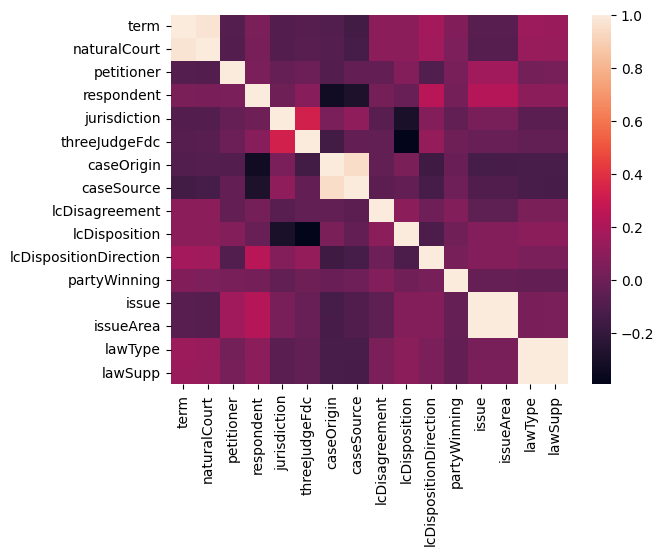

In [ ]:
# Display the correlation matrix of the current dataset to spot possibly redundant features.
correlation_matrix = train.drop(columns=["caseId", "respondent_issue", "petitioner_issue", "respondent_petitioner", "caseSource_issue"]).corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix)

In [ ]:
# Print a mutual information matrix for the features in relation to the target variable (partyWinning)
mutual_info_matrix = mutual_info_classif(train.drop(columns=["caseId", "partyWinning", "respondent_issue", "petitioner_issue", "respondent_petitioner", "caseSource_issue"]), train["partyWinning"], random_state=0)

# Print the mutual information matrix (found from research that it assesses any kind of relationship - linear or nonlinear).
print("Mutual Information Matrix")
print(mutual_info_matrix)

Mutual Information Matrix
[0.02029102 0.01839434 0.03777114 0.03804108 0.         0.
 0.01257193 0.01323646 0.00558989 0.00385725 0.00105355 0.03752972
 0.0057246  0.         0.02216113]


In [ ]:
"""
The following pairs of features were found to be highly correlated with each other:
1) Term and Natural Court
2) Case Origin and Case Source
3) Issue and Issue Area
4) Law Type and Law Supp
"""

"""
Select the features from each pair to remove based on the mutual information matrix
values (if a feature has a higher value in the mutual information matrix than another,
discard the feature with the lower value).
"""

highly_correlated_features_to_remove = ["naturalCourt", "caseOrigin", "issueArea", "lawType"]

# Remove these features from all splits
train.drop(columns=highly_correlated_features_to_remove, inplace=True)
val.drop(columns=highly_correlated_features_to_remove, inplace=True)
test.drop(columns=highly_correlated_features_to_remove, inplace=True)

/tmp/ipykernel_10366/3977528824.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.drop(columns=highly_correlated_features_to_remove, inplace=True)
/tmp/ipykernel_10366/3977528824.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val.drop(columns=highly_correlated_features_to_remove, inplace=True)
/tmp/ipykernel_10366/3977528824.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(columns=highly_correlated_features

In [ ]:
# Further split these train and test splits into X and y.
X_train = train.drop(columns=["partyWinning", "caseId"])
y_train = train["partyWinning"]
X_val = val.drop(columns=["partyWinning", "caseId"])
y_val = val["partyWinning"]
X_test = test.drop(columns=["partyWinning", "caseId"])
y_test = test["partyWinning"]

X_train.head()

,term,petitioner,respondent,jurisdiction,threeJudgeFdc,caseSource,lcDisagreement,lcDisposition,lcDispositionDirection,issue,lawSupp,respondent_issue,petitioner_issue,respondent_petitioner,caseSource_issue
0,1946,198.0,172.0,6.0,0.0,29.0,0.0,2.0,1.0,80180.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...
1,1946,100.0,27.0,1.0,0.0,30.0,0.0,2.0,1.0,10500.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...
2,1946,100.0,27.0,1.0,0.0,30.0,0.0,2.0,1.0,10500.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...
3,1946,100.0,27.0,1.0,0.0,30.0,0.0,2.0,1.0,10500.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...
4,1946,100.0,27.0,1.0,0.0,30.0,0.0,2.0,1.0,10500.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...


In [ ]:
# Initialize the features for ordinal encoding.
features_for_ordinal_encoding = ["respondent_issue", "petitioner_issue", "respondent_petitioner",
                                 "caseSource_issue"]

# Perform hyperparameter tuning
learning_rates = [0.01, 0.03, 0.05, 0.1, 0.2]
n_estimators_vals = [50, 100, 200, 300, 500]

best_crossval_log_loss = float("inf")
best_learning_rate = learning_rates[0]
best_n_estimator = n_estimators_vals[0]

for learning_rate in tqdm(learning_rates, desc="Using learning_rate"):
    for n_estimator in tqdm(n_estimators_vals, desc="Using n_estimator"):
        # Instantiate a model setting the parameters as appropriate.
        model = GradientBoostingClassifier(learning_rate=learning_rate, n_estimators=n_estimator, random_state=0)

        # Transform the interaction terms using ordinal encoding.
        ord_enc = OrdinalEncoder()
        enc_interaction_terms_train = pd.DataFrame(data=ord_enc.fit_transform(X_train[features_for_ordinal_encoding]),
                                                    columns=features_for_ordinal_encoding,
                                                    index=X_train.index)
        non_enc_columns_train = X_train.drop(columns=features_for_ordinal_encoding)
        X_train_transformed = pd.concat([non_enc_columns_train, enc_interaction_terms_train], axis=1)

        # Fit the model to the transformed training data.
        model.fit(X_train_transformed, y_train)

        # Transform the validation data.
        enc_interaction_terms_val = pd.DataFrame(data=ord_enc.transform(X_val[features_for_ordinal_encoding]),
                                                 columns=features_for_ordinal_encoding,
                                                 index=X_val.index)
        non_enc_columns_val = X_val.drop(columns=features_for_ordinal_encoding)
        X_val_transformed = pd.concat([non_enc_columns_val, enc_interaction_terms_val], axis=1)
        predicted_probabilities = model.predict_proba(X_val_transformed)
        current_log_loss = log_loss(y_val, predicted_probabilities)

        """
        Update the best validation log loss and the parameters corresponding
        to this log loss.
        """
        if best_crossval_log_loss > current_log_loss:
            best_crossval_log_loss = current_log_loss
            best_learning_rate = learning_rate
            best_n_estimator = n_estimator

        tqdm.write(f"Best validation log loss: {best_crossval_log_loss:.4f} | Params: lr={best_learning_rate}, n_est={best_n_estimator}")

Using learning_rate:   0%|          | 0/5 [00:00<?, ?it/s]

Using n_estimator:  20%|██        | 1/5 [00:03<00:14,  3.51s/it]

Best validation log loss: 0.6383 | Params: lr=0.01, n_est=50



Using n_estimator:  40%|████      | 2/5 [00:10<00:17,  5.81s/it]

Best validation log loss: 0.6351 | Params: lr=0.01, n_est=100



Using n_estimator:  60%|██████    | 3/5 [00:24<00:18,  9.13s/it]

Best validation log loss: 0.6336 | Params: lr=0.01, n_est=200



Using n_estimator:  80%|████████  | 4/5 [00:30<00:08,  8.14s/it]

Best validation log loss: 0.6336 | Params: lr=0.01, n_est=200



Using learning_rate:  20%|██        | 1/5 [00:38<02:35, 38.98s/it]

Best validation log loss: 0.6329 | Params: lr=0.01, n_est=500




Using n_estimator:  20%|██        | 1/5 [00:00<00:03,  1.28it/s]

Best validation log loss: 0.6329 | Params: lr=0.01, n_est=500



Using n_estimator:  40%|████      | 2/5 [00:02<00:03,  1.22s/it]

Best validation log loss: 0.6329 | Params: lr=0.01, n_est=500



Using n_estimator:  60%|██████    | 3/5 [00:05<00:04,  2.02s/it]

Best validation log loss: 0.6329 | Params: lr=0.01, n_est=500



Using n_estimator:  80%|████████  | 4/5 [00:10<00:03,  3.26s/it]

Best validation log loss: 0.6312 | Params: lr=0.03, n_est=300



Using learning_rate:  40%|████      | 2/5 [00:56<01:19, 26.64s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500




Using n_estimator:  20%|██        | 1/5 [00:00<00:03,  1.27it/s]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500



Using n_estimator:  40%|████      | 2/5 [00:02<00:03,  1.22s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500



Using n_estimator:  60%|██████    | 3/5 [00:06<00:04,  2.43s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500



Using n_estimator:  80%|████████  | 4/5 [00:10<00:03,  3.23s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500



Using learning_rate:  60%|██████    | 3/5 [01:15<00:45, 22.98s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500




Using n_estimator:  20%|██        | 1/5 [00:01<00:04,  1.04s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500



Using n_estimator:  40%|████      | 2/5 [00:02<00:03,  1.33s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500



Using n_estimator:  60%|██████    | 3/5 [00:05<00:04,  2.08s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500



Using n_estimator:  80%|████████  | 4/5 [00:09<00:03,  3.02s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500



Using learning_rate:  80%|████████  | 4/5 [01:33<00:21, 21.11s/it]

Best validation log loss: 0.6306 | Params: lr=0.03, n_est=500




Using n_estimator:  20%|██        | 1/5 [00:00<00:03,  1.26it/s]

Best validation log loss: 0.6299 | Params: lr=0.2, n_est=50



Using n_estimator:  40%|████      | 2/5 [00:02<00:03,  1.22s/it]

Best validation log loss: 0.6299 | Params: lr=0.2, n_est=50



Using n_estimator:  60%|██████    | 3/5 [00:05<00:04,  2.02s/it]

Best validation log loss: 0.6299 | Params: lr=0.2, n_est=50



Using n_estimator:  80%|████████  | 4/5 [00:11<00:03,  3.57s/it]

Best validation log loss: 0.6299 | Params: lr=0.2, n_est=50



Using learning_rate: 100%|██████████| 5/5 [01:52<00:00, 22.55s/it]

Best validation log loss: 0.6299 | Params: lr=0.2, n_est=50


In [ ]:
print("Best log_loss:", best_crossval_log_loss)
print("Best learning_rate:", best_learning_rate)
print("Best n_estimator:", best_n_estimator)

Best log_loss: 0.6299009356993086
Best learning_rate: 0.2
Best n_estimator: 50


In [ ]:
# Initialize the features for ordinal encoding.
features_for_ordinal_encoding = ["respondent_issue", "petitioner_issue", "respondent_petitioner",
                                 "caseSource_issue"]

# Perform hyperparameter tuning (stage 2)
max_depths = [1, 2, 3, 4, 5]
min_samples_leafs = [1, 2, 5, 10, 20, 50]

best_crossval_log_loss = float("inf")
best_max_depth = max_depths[0]
best_min_samples_leaf = min_samples_leafs[0]

for max_depth in tqdm(max_depths, desc="Using max_depth"):
    for min_samples_leaf in tqdm(min_samples_leafs, desc="Using min_samples_leaf"):
        # Instantiate a model setting the parameters as appropriate.
        model = GradientBoostingClassifier(learning_rate=best_learning_rate, n_estimators=best_n_estimator,
                                           max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=0)

        # Transform the interaction terms using ordinal encoding.
        ord_enc = OrdinalEncoder()
        enc_interaction_terms_train = pd.DataFrame(data=ord_enc.fit_transform(X_train[features_for_ordinal_encoding]),
                                                    columns=features_for_ordinal_encoding,
                                                    index=X_train.index)
        non_enc_columns_train = X_train.drop(columns=features_for_ordinal_encoding)
        X_train_transformed = pd.concat([non_enc_columns_train, enc_interaction_terms_train], axis=1)

        # Fit the model to the transformed training data.
        model.fit(X_train_transformed, y_train)

        # Transform the validation data.
        enc_interaction_terms_val = pd.DataFrame(data=ord_enc.transform(X_val[features_for_ordinal_encoding]),
                                                 columns=features_for_ordinal_encoding,
                                                 index=X_val.index)
        non_enc_columns_val = X_val.drop(columns=features_for_ordinal_encoding)
        X_val_transformed = pd.concat([non_enc_columns_val, enc_interaction_terms_val], axis=1)
        predicted_probabilities = model.predict_proba(X_val_transformed)
        current_log_loss = log_loss(y_val, predicted_probabilities)

        """
        Update the best validation log loss and the parameters corresponding
        to this log loss.
        """
        if best_crossval_log_loss > current_log_loss:
            best_crossval_log_loss = current_log_loss
            best_max_depth = max_depth
            best_min_samples_leaf = min_samples_leaf

        tqdm.write(f"Best validation log loss: {best_crossval_log_loss:.4f} | Params: max_depth={best_max_depth}, min_samples_leaf={best_min_samples_leaf}")

Using min_samples_leaf:   0%|          | 0/6 [00:00<?, ?it/s]

Using min_samples_leaf:  17%|█▋        | 1/6 [00:00<00:02,  2.00it/s]

Best validation log loss: 0.6335 | Params: max_depth=1, min_samples_leaf=1




Using min_samples_leaf:  33%|███▎      | 2/6 [00:00<00:01,  2.03it/s]

Best validation log loss: 0.6335 | Params: max_depth=1, min_samples_leaf=1




Using min_samples_leaf:  50%|█████     | 3/6 [00:01<00:01,  2.04it/s]

Best validation log loss: 0.6335 | Params: max_depth=1, min_samples_leaf=1




Using min_samples_leaf:  67%|██████▋   | 4/6 [00:01<00:00,  2.03it/s]

Best validation log loss: 0.6335 | Params: max_depth=1, min_samples_leaf=1




Using min_samples_leaf:  83%|████████▎ | 5/6 [00:02<00:00,  2.02it/s]

Best validation log loss: 0.6335 | Params: max_depth=1, min_samples_leaf=1




Using max_depth:  20%|██        | 1/5 [00:02<00:11,  2.97s/it]

Best validation log loss: 0.6335 | Params: max_depth=1, min_samples_leaf=1



Using min_samples_leaf:   0%|          | 0/6 [00:00<?, ?it/s]

Using min_samples_leaf:  17%|█▋        | 1/6 [00:00<00:03,  1.56it/s]

Best validation log loss: 0.6311 | Params: max_depth=2, min_samples_leaf=1




Using min_samples_leaf:  33%|███▎      | 2/6 [00:01<00:02,  1.67it/s]

Best validation log loss: 0.6311 | Params: max_depth=2, min_samples_leaf=1




Using min_samples_leaf:  50%|█████     | 3/6 [00:01<00:01,  1.73it/s]

Best validation log loss: 0.6306 | Params: max_depth=2, min_samples_leaf=5




Using min_samples_leaf:  67%|██████▋   | 4/6 [00:02<00:01,  1.74it/s]

Best validation log loss: 0.6306 | Params: max_depth=2, min_samples_leaf=10




Using min_samples_leaf:  83%|████████▎ | 5/6 [00:03<00:00,  1.38it/s]

Best validation log loss: 0.6306 | Params: max_depth=2, min_samples_leaf=10




Using max_depth:  40%|████      | 2/5 [00:07<00:11,  3.74s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using min_samples_leaf:  17%|█▋        | 1/6 [00:00<00:03,  1.28it/s]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50



Using min_samples_leaf:  33%|███▎      | 2/6 [00:01<00:03,  1.28it/s]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50



Using min_samples_leaf:  50%|█████     | 3/6 [00:02<00:02,  1.28it/s]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50



Using min_samples_leaf:  67%|██████▋   | 4/6 [00:03<00:01,  1.28it/s]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50



Using min_samples_leaf:  83%|████████▎ | 5/6 [00:03<00:00,  1.26it/s]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50



Using max_depth:  60%|██████    | 3/5 [00:11<00:08,  4.19s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50



Using min_samples_leaf:   0%|          | 0/6 [00:00<?, ?it/s]

Using min_samples_leaf:  17%|█▋        | 1/6 [00:00<00:04,  1.00it/s]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using min_samples_leaf:  33%|███▎      | 2/6 [00:02<00:04,  1.19s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using min_samples_leaf:  50%|█████     | 3/6 [00:03<00:03,  1.31s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using min_samples_leaf:  67%|██████▋   | 4/6 [00:04<00:02,  1.26s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using min_samples_leaf:  83%|████████▎ | 5/6 [00:05<00:01,  1.17s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using max_depth:  80%|████████  | 4/5 [00:18<00:05,  5.29s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50



Using min_samples_leaf:   0%|          | 0/6 [00:00<?, ?it/s]

Using min_samples_leaf:  17%|█▋        | 1/6 [00:01<00:06,  1.25s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using min_samples_leaf:  33%|███▎      | 2/6 [00:02<00:05,  1.25s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using min_samples_leaf:  50%|█████     | 3/6 [00:03<00:03,  1.26s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using min_samples_leaf:  67%|██████▋   | 4/6 [00:05<00:02,  1.25s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using min_samples_leaf:  83%|████████▎ | 5/6 [00:06<00:01,  1.25s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50




Using max_depth: 100%|██████████| 5/5 [00:26<00:00,  5.29s/it]

Best validation log loss: 0.6281 | Params: max_depth=2, min_samples_leaf=50


In [ ]:
# Instatiate a model with the best parameters
model = GradientBoostingClassifier(learning_rate=best_learning_rate, n_estimators=best_n_estimator,
                                   max_depth=best_max_depth, min_samples_leaf=best_min_samples_leaf, random_state=0)

# Transform the interaction terms using ordinal encoding.
ord_enc = OrdinalEncoder()
enc_interaction_terms_train = pd.DataFrame(data=ord_enc.fit_transform(X_train[features_for_ordinal_encoding]),
                                                    columns=features_for_ordinal_encoding,
                                                    index=X_train.index)
non_enc_columns_train = X_train.drop(columns=features_for_ordinal_encoding)
X_train_transformed = pd.concat([non_enc_columns_train, enc_interaction_terms_train], axis=1)

# Fit the model to the transformed training data.
model.fit(X_train_transformed, y_train)

# Transform the validation data.
enc_interaction_terms_val = pd.DataFrame(data=ord_enc.transform(X_val[features_for_ordinal_encoding]),
                                                 columns=features_for_ordinal_encoding,
                                                 index=X_val.index)
non_enc_columns_val = X_val.drop(columns=features_for_ordinal_encoding)
X_val_transformed = pd.concat([non_enc_columns_val, enc_interaction_terms_val], axis=1)

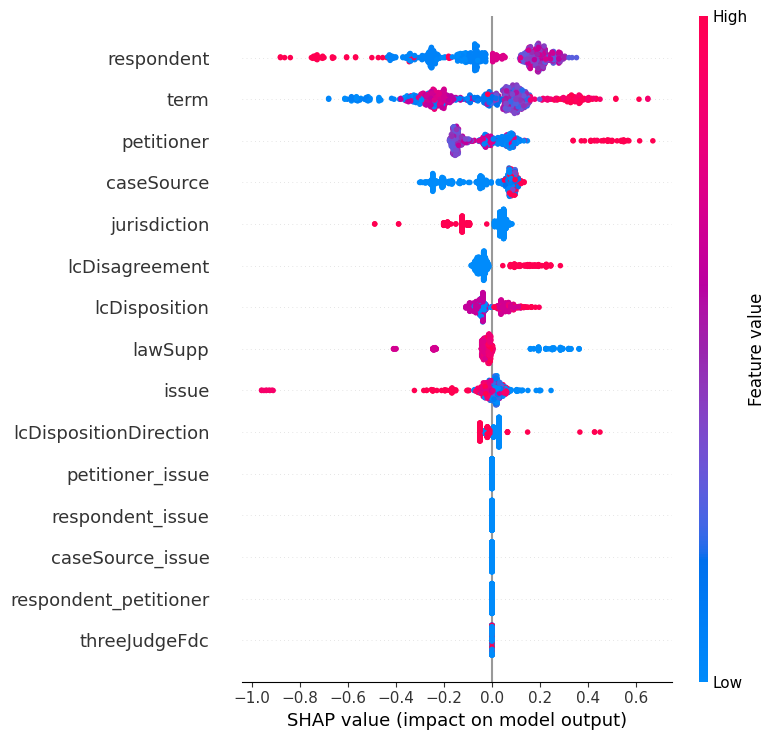

In [ ]:
# Make predictions for the validation set.
val_predictions = model.predict(X_val_transformed)

# Filter for observations where the validation predictions do not align with the actual case outcomes.
X_val_incorrect = X_val_transformed[y_val != val_predictions]

# Create SHAP model using TreeExplainer
tree_explainer = shap.TreeExplainer(model)

# Generate a plot showing the impact of the features on the incorrect validation set predictions
incorrect_shap_values = tree_explainer.shap_values(X_val_incorrect)
shap.summary_plot(incorrect_shap_values, X_val_incorrect)

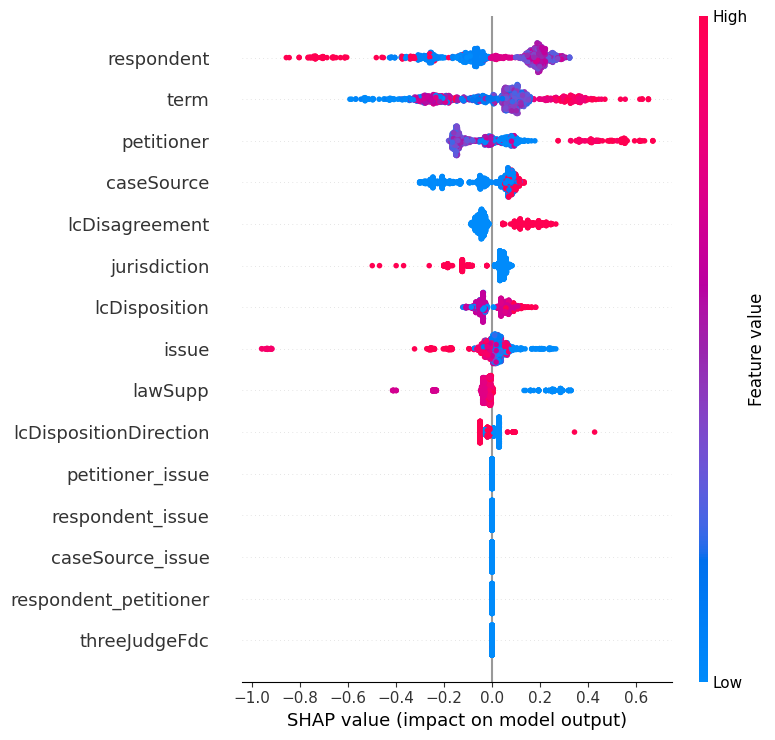

In [ ]:
# Filter for observations where the validation predictions align with the actual case outcomes.
X_val_correct = X_val_transformed[y_val == val_predictions]

# Generate a plot showing the impact of the features on the incorrect validation set predictions
correct_shap_values = tree_explainer.shap_values(X_val_correct)
shap.summary_plot(correct_shap_values, X_val_correct)

In [ ]:
# Transform the test data.
enc_interaction_terms_test = pd.DataFrame(data=ord_enc.transform(X_test[features_for_ordinal_encoding]),
                                                 columns=features_for_ordinal_encoding,
                                                 index=X_test.index)
non_enc_columns_test = X_test.drop(columns=features_for_ordinal_encoding)
X_test_transformed = pd.concat([non_enc_columns_test, enc_interaction_terms_test], axis=1)

# Perform model evaluation.
predicted_probabilities = model.predict_proba(X_test_transformed)
predictions = model.predict(X_test_transformed)
test_log_loss = log_loss(y_test, predicted_probabilities)
test_accuracy = accuracy_score(y_test, predictions)
print("Test Log Loss:", test_log_loss)
print("Test Accuracy:", test_accuracy)

Test Log Loss: 0.6143793766124487
Test Accuracy: 0.6711983887210473
